# Session 4, Notebook 0: The Simplest OLG, Two Periods, One Euler Equation

**Course:** Deep Learning for Solving Dynamic Models - University of Padova, 23-24 September 2026  
**Session:** Day 1, 14:25 - 15:25 - OLG models with DEQNs  
**Slides:** `04_OLG_Models_DEQNs.pdf`, Part I½  
**Notebook role:** warm-up  
**Author:** Simon Scheidegger (HEC, University of Lausanne)  

---

Before the six-cohort model of `04_01`, this notebook shows the Deep Equilibrium Net on the smallest overlapping-generations economy: Diamond's (1965) two-period model. One cohort saves, one cohort eats, so there is exactly **one policy function and one Euler equation**. The structure of the six-cohort and 56-cohort notebooks is already visible here, and the closed form gives an exact check: on the states the economy visits the learned savings fraction is within $5\times10^{-4}$ of $\beta/(1+\beta)$, in about a minute on a laptop CPU.

In the two-period model next period's *policy* never enters the Euler equation (the old simply consume what they have), which is what makes it the simplest case. In the six-cohort model it does, and that recursion through the network's own future behaviour is what the DEQN handles.


In [1]:
SEED = 0

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)
plt.rcParams["font.size"] = 12

import os
SAVE_FIGURES = True   # True writes the slide figure to ../../slides/figures/ (or $OLG_FIGURE_DIR)
FIGURE_DIR = os.environ.get("OLG_FIGURE_DIR", os.path.join("..", "..", "slides", "figures"))


def savefig(fig, name):
    if SAVE_FIGURES:
        os.makedirs(FIGURE_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIGURE_DIR, name), bbox_inches="tight")


E0000 00:00:1788898456.397330  215844 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788898456.403196  215844 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 1. The model

---

**Households.** A cohort lives two periods. When *young* it supplies one unit of labor, earns the wage $w_t$, consumes $c^y_t$ and saves $s_t$ in capital:

$$
  c^y_t + s_t = w_t .
$$

When *old* it supplies no labor, sells its capital to the firm and consumes the proceeds:

$$
  c^o_{t+1} = r_{t+1}\, s_t ,
$$

where $r_{t+1}$ is the gross return on capital (rental rate plus undepreciated capital). Preferences are $\ln c^y_t + \beta\,\mathbb{E}_t \ln c^o_{t+1}$ with $\beta = 0.7$.

**Firm and prices.** The same Cobb–Douglas technology as in `04_01`, $f(K, L, z) = \eta(z) K^\alpha L^{1-\alpha} + (1-\delta(z))K$ with $\alpha = 0.3$, aggregate labor $L = 1$ (only the young work) and aggregate capital $K_t = s_{t-1}$: the capital stock *is* the saving of last period's young, now held by the old. Competitive prices are

$$
  r_t = \alpha\,\eta(z_t)\,K_t^{\alpha - 1} + 1 - \delta(z_t), \qquad
  w_t = (1-\alpha)\,\eta(z_t)\,K_t^{\alpha}.
$$

**Shocks.** Four i.i.d. aggregate states combining $\eta \in \{0.95, 1.05\}$ and $\delta \in \{0.5, 0.9\}$, each with probability $1/4$, identical to the six-cohort notebook.

**State.** Everything at date $t$ is pinned down by $(z_t, k_t)$ with $k_t = K_t$ the capital held by the old.

## 2. The Euler equation and its closed form

Substituting the budget constraints, the young choose $s$ to maximise $\ln(w_t - s) + \beta\,\mathbb{E}_t \ln(r_{t+1} s)$. Because $\ln(r_{t+1}s) = \ln r_{t+1} + \ln s$, the return separates from the choice, and the first-order condition is

$$
  \frac{1}{w_t - s_t} \;=\; \beta\,\mathbb{E}_t\!\left[\frac{r_{t+1}}{r_{t+1}\, s_t}\right] \;=\; \frac{\beta}{s_t}
  \qquad\Longrightarrow\qquad
  s_t = \frac{\beta}{1+\beta}\, w_t .
$$

The young save a **fixed fraction of the wage, whatever the distribution of returns**: $\beta/(1+\beta) = 0.4118$ for $\beta = 0.7$. Two things made this work, log utility (the return cancels) and the fact that the old have no labor income (so the wage today is the household's entire lifetime resource). Compare with the six-cohort formula $\beta_h = \beta(1-\beta^{A-h})/(1-\beta^{A-h+1})$: at $A = 2$, $h = 1$ it gives exactly $\beta/(1+\beta)$. This is the number the network has to find.


In [2]:
# ============================================================
# Parameters (same technology and shocks as the six-cohort notebook)
# ============================================================
BETA = 0.70
ALPHA = 0.30
NUM_SHOCKS = 4
TFP = np.array([0.95, 1.05, 0.95, 1.05], dtype=np.float32)
DEPR = np.array([0.50, 0.50, 0.90, 0.90], dtype=np.float32)
PI = np.full((NUM_SHOCKS, NUM_SHOCKS), 0.25, dtype=np.float32)

SAVINGS_RATE_CLOSED_FORM = BETA / (1.0 + BETA)
print(f"closed-form savings rate beta/(1+beta) = {SAVINGS_RATE_CLOSED_FORM:.4f}")

TFP_TF = tf.constant(TFP.reshape(-1, 1))
DEPR_TF = tf.constant(DEPR.reshape(-1, 1))
PI_TF = tf.constant(PI)


def prices(z, K):
    """Gross return r and wage w at aggregate state z with capital K (L = 1)."""
    K = tf.maximum(K, 1e-8)
    eta = tf.gather(TFP_TF, z)
    depr = tf.gather(DEPR_TF, z)
    r = ALPHA * eta * tf.pow(K, ALPHA - 1.0) + (1.0 - depr)
    w = (1.0 - ALPHA) * eta * tf.pow(K, ALPHA)
    return r, w


closed-form savings rate beta/(1+beta) = 0.4118


## 3. The DEQN

---

The unknown is one function, $s = f(z, k)$. We approximate it with a small network whose output is a **savings fraction** $\hat\sigma(z, k) \in (0, 1)$ of the wage, $\hat s = \hat\sigma\, w(z, k)$, so that $0 \le \hat s \le w$ holds by construction and the young's consumption $w - \hat s$ is always positive. The input is the state $(z, k)$ plus the prices it implies, pure feature engineering, as in every DEQN of this course.

The residual is the Euler equation in *relative* form. Given the network's choice at $(z, k)$, tomorrow's capital is $K' = \hat s$, tomorrow's return $r'(z', K')$ follows for each of the four possible shocks, the old consume $c^{o\prime} = r'\hat s$, and

$$
  e(z, k) \;=\; \frac{\bigl(\beta\,\mathbb{E}[\, r'\,/\,c^{o\prime}\,]\bigr)^{-1}}{w - \hat s} \;-\; 1 .
$$

The numerator is the consumption that would satisfy the Euler equation exactly; the denominator is the consumption the network chose; the residual is zero if and only if they agree. The expectation is the exact four-term sum. The code below builds $r'$ and $c^{o\prime}$ the general way even though they cancel algebraically, so that the pattern carries over to the six-cohort case, where nothing cancels.


In [3]:
# ============================================================
# Network, policy, residual
# ============================================================
def features(z, k):
    """Network input: one-hot shock, capital, and the prices they imply."""
    r, w = prices(z, k)
    return tf.concat([tf.one_hot(z, NUM_SHOCKS), k, r, w], axis=1)


FEATURE_DIM = NUM_SHOCKS + 3

model = keras.Sequential([
    keras.layers.Input(shape=(FEATURE_DIM,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    # Zero-initialising the LAST layer only (not the hidden ones): the raw output starts at 0,
    # so sigmoid gives sigma = 0.5 everywhere and the initial policy is "save half the wage".
    # A neutral, feasible starting guess, which is not the same thing as zero-initialising a net.
    keras.layers.Dense(1, activation=None, kernel_initializer="zeros", bias_initializer="zeros"),
])


def policy(z, k):
    """Savings s = sigma(z,k) * w(z,k) with sigma in (0,1)."""
    _, w = prices(z, k)
    sigma = tf.nn.sigmoid(model(features(z, k)))
    return sigma * w, sigma


# @tf.function compiles the body into a graph, which is what makes 2000 steps take a minute
# rather than several.  The cost: a print() inside the function runs only during tracing.
@tf.function
def residual(z, k):
    s, _ = policy(z, k)
    _, w = prices(z, k)
    c_young = w - s
    K_next = s                                   # all of tomorrow's capital is today's saving
    expected = tf.zeros_like(s)
    for shock in range(NUM_SHOCKS):              # exact expectation over the four shocks
        z_next = tf.fill(tf.shape(z), shock)
        r_next, _ = prices(z_next, K_next)
        c_old_next = r_next * s
        expected += PI[0, shock] * r_next / c_old_next
    return 1.0 / (BETA * expected) / c_young - 1.0


@tf.function
def loss_fn(z, k):
    return tf.reduce_mean(tf.square(residual(z, k)))


## 4. Training

---

The training cloud is generated by simulating the economy under the network's own current policy: start 512 economies at random capital levels, and after every gradient step move each one forward by one period with a fresh shock. After a few hundred steps the cloud lives on the ergodic set of the learned policy, which is exactly where we need the Euler equation to hold. This is the same "simulate, then take gradient steps" loop as in the six-cohort notebook, stripped to its essentials.


In [4]:
# ============================================================
# Simulate-and-train loop
# ============================================================
N_STATES = 512
N_STEPS = 2000
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

z = tf.constant(rng.integers(0, NUM_SHOCKS, size=N_STATES), dtype=tf.int32)
k = tf.constant(rng.uniform(0.01, 1.0, size=(N_STATES, 1)), dtype=tf.float32)
history = []

for step in range(N_STEPS):
    with tf.GradientTape() as tape:
        loss = loss_fn(z, k)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    history.append(float(loss))

    # Advance the cloud one period under the current policy: tomorrow's capital is today's saving.
    # stop_gradient marks the new states as DATA, not as something to differentiate through.  The
    # gradient step above already used them as fixed inputs, so this is a fixed-point iteration
    # (solve on the current cloud, then move the cloud), not differentiation through time.
    s, _ = policy(z, k)
    k = tf.stop_gradient(s)
    z = tf.constant(rng.integers(0, NUM_SHOCKS, size=N_STATES), dtype=tf.int32)

    if step % 250 == 0 or step == N_STEPS - 1:
        _, sigma = policy(z, k)
        print(f"step {step:5d} | log10 loss = {np.log10(max(history[-1], 1e-30)):6.2f} | "
              f"mean savings fraction = {float(tf.reduce_mean(sigma)):.4f} (closed form {SAVINGS_RATE_CLOSED_FORM:.4f})")


step     0 | log10 loss =  -0.74 | mean savings fraction = 0.4988 (closed form 0.4118)


step   250 | log10 loss =  -5.70 | mean savings fraction = 0.4118 (closed form 0.4118)


step   500 | log10 loss =  -5.94 | mean savings fraction = 0.4117 (closed form 0.4118)


step   750 | log10 loss =  -5.86 | mean savings fraction = 0.4118 (closed form 0.4118)


step  1000 | log10 loss =  -5.99 | mean savings fraction = 0.4118 (closed form 0.4118)


step  1250 | log10 loss =  -6.01 | mean savings fraction = 0.4118 (closed form 0.4118)


step  1500 | log10 loss =  -6.12 | mean savings fraction = 0.4118 (closed form 0.4118)


step  1750 | log10 loss =  -6.15 | mean savings fraction = 0.4118 (closed form 0.4118)


step  1999 | log10 loss =  -6.21 | mean savings fraction = 0.4117 (closed form 0.4118)


## 5. Validation against the closed form

---

Two checks. First, **on the states the economy actually visits**, the final training cloud, which after 2000 periods sits on the ergodic set of the learned policy, the learned savings fraction should be $0.4118$ to three or four decimals, with Euler residuals at the $10^{-3}$ level or below. That is the validation.

Second, a deliberate look **off** the ergodic set: evaluate the policy on a wide grid of capital levels, most of which the economy never reaches. There the loss never constrained the network, and the fraction drifts. This is the reason every DEQN in this course trains on a *simulated* cloud rather than a box of random states: the equilibrium conditions only need to hold where the equilibrium lives, and that is the only place the network is asked to get them right.


On the ergodic cloud (final training states)
  capital range visited      : [0.157, 0.182]
  learned savings fraction   : mean 0.41175, min 0.41131, max 0.41223
  closed form                : 0.41176
  max |fraction error|       : 4.69e-04
  mean |Euler residual|      : 5.20e-04

On a wide grid k in [0.02, 1.0]
  max |fraction error| inside the visited range : 4.64e-04
  max |fraction error| outside it               : 8.22e-02   <- never trained there


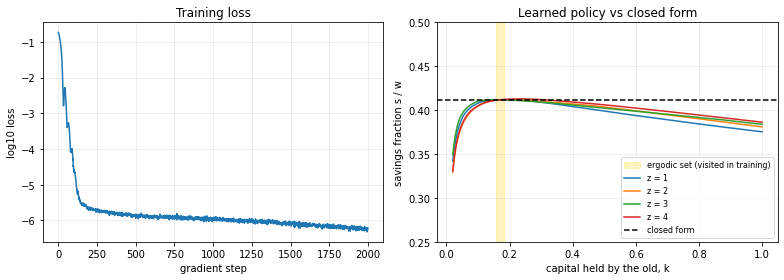

In [5]:
# ============================================================
# Validation
# ============================================================
# (i) On the ergodic cloud: the states the trained economy visits.
s_erg, sigma_erg = policy(z, k)
e_erg = residual(z, k)
k_erg = k.numpy()[:, 0]
print("On the ergodic cloud (final training states)")
print(f"  capital range visited      : [{k_erg.min():.3f}, {k_erg.max():.3f}]")
print(f"  learned savings fraction   : mean {float(tf.reduce_mean(sigma_erg)):.5f}, "
      f"min {float(tf.reduce_min(sigma_erg)):.5f}, max {float(tf.reduce_max(sigma_erg)):.5f}")
print(f"  closed form                : {SAVINGS_RATE_CLOSED_FORM:.5f}")
print(f"  max |fraction error|       : {float(tf.reduce_max(tf.abs(sigma_erg - SAVINGS_RATE_CLOSED_FORM))):.2e}")
print(f"  mean |Euler residual|      : {float(tf.reduce_mean(tf.abs(e_erg))):.2e}")

# (ii) Off the ergodic set: a wide grid the economy mostly never visits.
z_test = tf.constant(np.repeat(np.arange(NUM_SHOCKS), 250), dtype=tf.int32)
k_test = tf.constant(np.tile(np.linspace(0.02, 1.0, 250), NUM_SHOCKS).reshape(-1, 1), dtype=tf.float32)
s_test, sigma_test = policy(z_test, k_test)
inside = (k_test.numpy()[:, 0] >= k_erg.min()) & (k_test.numpy()[:, 0] <= k_erg.max())
err_test = np.abs(sigma_test.numpy()[:, 0] - SAVINGS_RATE_CLOSED_FORM)
print("\nOn a wide grid k in [0.02, 1.0]")
print(f"  max |fraction error| inside the visited range : {err_test[inside].max():.2e}")
print(f"  max |fraction error| outside it               : {err_test[~inside].max():.2e}   <- never trained there")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.log10(np.maximum(history, 1e-30)))
axes[0].set_xlabel("gradient step"); axes[0].set_ylabel("log10 loss"); axes[0].set_title("Training loss")
axes[0].grid(alpha=0.25)
axes[1].axvspan(k_erg.min(), k_erg.max(), color="gold", alpha=0.25, label="ergodic set (visited in training)")
for shock in range(NUM_SHOCKS):
    m = z_test.numpy() == shock
    axes[1].plot(k_test.numpy()[m, 0], sigma_test.numpy()[m, 0], label=f"z = {shock + 1}")
axes[1].axhline(SAVINGS_RATE_CLOSED_FORM, color="black", linestyle="--", label="closed form")
axes[1].set_xlabel("capital held by the old, k"); axes[1].set_ylabel("savings fraction s / w")
axes[1].set_title("Learned policy vs closed form"); axes[1].set_ylim(0.25, 0.5); axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
savefig(fig, "olg2_savings_fraction.pdf")
plt.show()


## What carries over

---

Open `04_01_OLG_Analytic_DEQN_persistent.ipynb` next. Three things change and nothing else:

1. **More cohorts.** Six instead of two, so the state is $(z, k^1, \ldots, k^6)$ and the network has five outputs, one savings decision per cohort that is not about to die.
2. **Five Euler equations instead of one**, stacked into the same mean-squared loss.
3. **Tomorrow's policy matters.** A 40-year-old's consumption next period depends on what the network will decide for a 41-year-old, so the residual evaluates the network at the next state. That recursion, absent here because the old just eat, is the heart of a Deep Equilibrium Net.

The closed form survives all three, for the same two reasons as here: log utility and no future labor income. The 56-cohort benchmark of `04_02` drops both, and the closed form with them.
